<a href="https://colab.research.google.com/github/Harsha-chikkala/ML-Based-Loan-Approval-Decision-Support-System/blob/main/ML_Based_Loan_Approval_Decision_Support_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

# 1. Load the dataset
df = pd.read_csv('/content/loan_full_labeled.csv')



In [3]:
# 2. Initial Structural Audit
print(f"Dataset Dimensions: {df.shape}")
print("\nMissing Values per Column (Before):")
print(df.isnull().sum())



Dataset Dimensions: (981, 13)

Missing Values per Column (Before):
Loan_ID               0
Gender               24
Married               3
Dependents           25
Education             0
Self_Employed        55
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           27
Loan_Amount_Term     20
Credit_History       79
Property_Area         0
Loan_Status           0
dtype: int64


In [4]:
# 3. Drop non-actionable/non-informative features immediately
# This prevents them from being imputed or encoded
cols_to_drop = ['Loan_ID', 'Property_Area']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print(f"\nRemaining Columns: {df.columns.tolist()}")


Remaining Columns: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Loan_Status']


In [5]:
from sklearn.impute import SimpleImputer

# Identify column types
num_cols = df.select_dtypes(exclude=['object']).columns
cat_cols = df.select_dtypes(include=['object']).columns.drop('Loan_Status')



In [6]:
# 4. Fill Numerical NaNs (Median)
imputer_num = SimpleImputer(strategy='median')
df[num_cols] = imputer_num.fit_transform(df[num_cols])



In [7]:
# 5. Fill Categorical NaNs (Mode/Most Frequent)
imputer_cat = SimpleImputer(strategy='most_frequent')
df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])



In [8]:
# 6. VERIFICATION STEP: Final Check for NaNs
null_count = df.isnull().sum().sum()
if null_count == 0:
    print("No remaining Nulls/NaNs in the dataset.")
else:
    print(f"{null_count} nulls still remain.")

No remaining Nulls/NaNs in the dataset.


In [9]:
# 7. Encode Target (Approved=1, Rejected=0)
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})


In [10]:
# 8. One-Hot Encode Categorical Features
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(df_encoded['Loan_Status'].value_counts(normalize=True))


Loan_Status
1    0.719674
0    0.280326
Name: proportion, dtype: float64


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 9. Define Features and Target
X = df_encoded.drop('Loan_Status', axis=1)
y = df_encoded['Loan_Status']



In [12]:
# 10. Stratified Split (To preserve the 72/28 ratio in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



In [13]:
# 11. Fit scaler only on Training Data to avoid Data Leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for interpretability in the next step
X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X.columns)


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# 2.1 Initialize and Train Logistic Regression
model = LogisticRegression(solver='liblinear', random_state=42)
model.fit(X_train_final, y_train)

# 2.2 Prediction: Get BOTH Class Labels and Probabilities
y_pred = model.predict(X_test_final)
y_probs = model.predict_proba(X_test_final)[:, 1] # Probability of Approval (Class 1)

# 2.3 Initial Performance Check
print("--- Model Performance Audit ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_probs):.4f}")

--- Model Performance Audit ---
              precision    recall  f1-score   support

           0       0.86      0.56      0.68        55
           1       0.85      0.96      0.90       142

    accuracy                           0.85       197
   macro avg       0.86      0.76      0.79       197
weighted avg       0.85      0.85      0.84       197

ROC-AUC Score: 0.8150


/tmp/ipython-input-3598847349.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=feature_importance_df, palette='viridis')


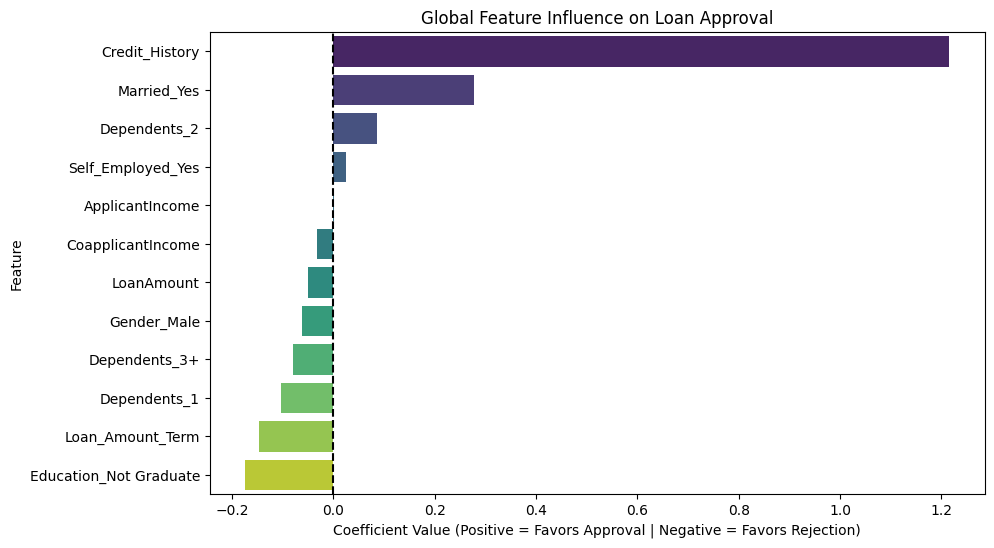


--- Key Insights ---
Strongest Approval Driver: Credit_History
Strongest Rejection Driver: Education_Not Graduate


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 3.1

# Extract Coefficients
importance = model.coef_[0]
feature_names = X.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': importance
}).sort_values(by='Coefficient', ascending=False)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Global Feature Influence on Loan Approval')
plt.axvline(x=0, color='black', linestyle='--')
plt.xlabel('Coefficient Value (Positive = Favors Approval | Negative = Favors Rejection)')
plt.show()

print("\n--- Key Insights ---")
top_positive = feature_importance_df.iloc[0]['Feature']
top_negative = feature_importance_df.iloc[-1]['Feature']
print(f"Strongest Approval Driver: {top_positive}")
print(f"Strongest Rejection Driver: {top_negative}")

In [16]:
def get_decision(prob):
    if prob >= 0.70:
        return 'APPROVE'
    elif prob >= 0.40:
        return 'REVIEW'
    else:
        return 'REJECT'

# Apply the logic to our test results
results_df = pd.DataFrame({
    'Actual_Status': y_test.values,
    'Approval_Probability': y_probs
})

results_df['Decision'] = results_df['Approval_Probability'].apply(get_decision)

print("--- Decision Support System Output (First 5 Samples) ---")
print(results_df.head())

# Distribution of Decisions
print("\n--- Business Decision Distribution ---")
print(results_df['Decision'].value_counts(normalize=True) * 100)

--- Decision Support System Output (First 5 Samples) ---
   Actual_Status  Approval_Probability Decision
0              1              0.803578  APPROVE
1              1              0.851806  APPROVE
2              1              0.917079  APPROVE
3              1              0.635797   REVIEW
4              1              0.745320  APPROVE

--- Business Decision Distribution ---
Decision
APPROVE    78.680203
REJECT     18.274112
REVIEW      3.045685
Name: proportion, dtype: float64


In [19]:
def generate_recommendation(applicant_index, features_df, model, scaler, original_df):
    # 1. Get Probability
    applicant_data = features_df.iloc[[applicant_index]]
    prob = model.predict_proba(applicant_data)[0, 1]

    # 2. Determine Decision Category
    if prob >= 0.70:
        decision, color = "APPROVE", "\033[92m"
    elif prob >= 0.40:
        decision, color = "REVIEW", "\033[93m"
    else:
        decision, color = "REJECT", "\033[91m"

    # 3. Calculate Local Feature Contribution
    contributions = model.coef_[0] * applicant_data.values[0]
    contrib_df = pd.DataFrame({
        'Feature': features_df.columns,
        'Contribution': contributions,
        'Raw_Value': applicant_data.values[0]
    }).sort_values(by='Contribution')

    print(f"--- 📄 Optimized Credit Report: Applicant {applicant_index} ---")
    print(f"Approval Probability: {prob:.2%}")
    print(f"Decision Status: {color}{decision}\033[0m")

    print("\n💡 Key Factors for This Decision:")

    # Logic for Negative Drivers (Risks)
    # We only show them if the contribution is significantly negative (< -0.1)
    risks = contrib_df[contrib_df['Contribution'] < -0.1]
    for _, row in risks.iterrows():
        feat = row['Feature']
        if 'Credit_History' in feat:
            print(f"- [RISK] Credit History: Previous repayment issues identified.")
        elif 'LoanAmount' in feat:
            print(f"- [RISK] Loan Size: High debt-to-income ratio for this request.")
        elif 'Income' in feat:
            print(f"- [RISK] Income: Reported income is below preferred threshold for this loan size.")
        elif 'Education_Not Graduate' in feat and row['Raw_Value'] > 0:
            print(f"- [RISK] Education: Applicant is not a graduate, which may affect long-term stability.")

    # Logic for Positive Drivers (Strengths)
    # If the contribution is positive (> 0.1)
    strengths = contrib_df[contrib_df['Contribution'] > 0.1].sort_values(by='Contribution', ascending=False)
    for _, row in strengths.iterrows():
        feat = row['Feature']
        # If 'Not Graduate' contribution is positive and Raw_Value is 0, it means they ARE a graduate
        if 'Education_Not Graduate' in feat and row['Raw_Value'] <= 0:
            print(f"- [STRENGTH] Education: Graduate status provides higher confidence in income stability.")
        elif 'Credit_History' in feat and row['Raw_Value'] > 0:
            print(f"- [STRENGTH] Credit History: Excellent track record of previous repayments.")
        elif 'Married_Yes' in feat and row['Raw_Value'] > 0:
            print(f"- [STRENGTH] Stability: Married status is correlated with lower default risk in this pool.")
        elif 'LoanAmount' in feat and row['Contribution'] > 0.3:
            print(f"- [STRENGTH] Loan Size: The requested amount is well within safe lending limits.")

# --- Run the Fixed Engine ---
generate_recommendation(89, X_test_final, model, scaler, X_test)

--- 📄 Optimized Credit Report: Applicant 89 ---
Approval Probability: 84.73%
Decision Status: APPROVE

💡 Key Factors for This Decision:
- [STRENGTH] Credit History: Excellent track record of previous repayments.
- [STRENGTH] Stability: Married status is correlated with lower default risk in this pool.


In [18]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# 1. Create Input Widgets based on your dataset features
style = {'description_width': 'initial'}

# Categorical Inputs
gender_w = widgets.Dropdown(options=['Male', 'Female'], description='Gender:', style=style)
married_w = widgets.Dropdown(options=['Yes', 'No'], description='Married:', style=style)
dependents_w = widgets.Dropdown(options=['0', '1', '2', '3+'], description='Dependents:', style=style)
education_w = widgets.Dropdown(options=['Graduate', 'Not Graduate'], description='Education:', style=style)
self_emp_w = widgets.Dropdown(options=['Yes', 'No'], description='Self Employed:', style=style)
credit_hist_w = widgets.Dropdown(options=[('Clear History (1.0)', 1.0), ('Poor History (0.0)', 0.0)], description='Credit History:', style=style)

# Numerical Inputs
app_income_w = widgets.IntSlider(value=5000, min=150, max=80000, step=100, description='Applicant Income:', style=style)
coapp_income_w = widgets.IntSlider(value=0, min=0, max=40000, step=100, description='Co-applicant Income:', style=style)
loan_amt_w = widgets.IntSlider(value=150, min=10, max=700, step=5, description='Loan Amount (k):', style=style)
loan_term_w = widgets.Dropdown(options=[(str(i), i) for i in [12, 36, 60, 84, 120, 180, 240, 300, 360, 480]], value=360, description='Term (Days):', style=style)

predict_btn = widgets.Button(description="Assess Loan Application", button_style='primary')
output = widgets.Output()

# 2. Prediction Logic for Manual Input
def on_predict_clicked(b):
    with output:
        clear_output()

        # Build raw data dictionary
        raw_input = {
            'Gender': gender_w.value,
            'Married': married_w.value,
            'Dependents': dependents_w.value,
            'Education': education_w.value,
            'Self_Employed': self_emp_w.value,
            'ApplicantIncome': app_income_w.value,
            'CoapplicantIncome': coapp_income_w.value,
            'LoanAmount': loan_amt_w.value,
            'Loan_Amount_Term': loan_term_w.value,
            'Credit_History': credit_hist_w.value
        }

        # Preprocessing to match training format
        input_df = pd.DataFrame([raw_input])

        # Apply the same mapping/encoding as training
        input_encoded = pd.get_dummies(input_df)

        # Ensure all columns from training are present (and in correct order)
        for col in X.columns:
            if col not in input_encoded.columns:
                input_encoded[col] = 0
        input_encoded = input_encoded[X.columns]

        # Scale
        input_scaled = scaler.transform(input_encoded)
        input_final = pd.DataFrame(input_scaled, columns=X.columns)

        # Generate the recommendation using our existing function
        # We pass 0 because it's the only row in our new input_final
        generate_recommendation(0, input_final, model, scaler, input_df)

predict_btn.on_click(on_predict_clicked)

# 3. Display Dashboard
print("--- 🏦 Loan Approval Decision Support Dashboard ---")
input_grid = widgets.VBox([
    widgets.HBox([gender_w, married_w]),
    widgets.HBox([dependents_w, education_w]),
    widgets.HBox([self_emp_w, credit_hist_w]),
    widgets.HBox([app_income_w, coapp_income_w]),
    widgets.HBox([loan_amt_w, loan_term_w]),
    predict_btn,
    output
])
display(input_grid)

--- 🏦 Loan Approval Decision Support Dashboard ---
